In [2]:
import os

print("Current Folder:")
print(os.getcwd())

print("\nFiles:")
print(os.listdir())

Current Folder:
/Users/purnimayadav/nishant

Files:
['Untitled.ipynb', '.ipynb_checkpoints']


In [3]:
import os

os.chdir("/Users/purnimayadav/Downloads")

print("Current Folder:", os.getcwd())
print(os.listdir()[:20])

Current Folder: /Users/purnimayadav/Downloads
['photo_2022-11-13 14.02.47.jpeg', 'Morphological Image Processing.pptx', 'anydesk.dmg', 'MO_SIGNATURE_RESIZED.JPG', 'VIPL2275 (1).JPG', 'Document 6.docx', 'WhatsApp Image 2023-11-15 at 8.10.55 PM.jpeg', 'googlechrome.dmg', 'WhatsApp Image 2023-11-15 at 8.10.45 PM.jpeg', 'Gemini_Generated_Image_glnp9xglnp9xglnp.png', 'VIPL2805.JPG', 'Stylish teaching resume.docx', 'Joint Entrance Examination (Main) _ India (1).pdf', 'my docs copy', 'Visual Studio Code.app', 'VIPL2332 (1).JPG', 'fake_voice-3.ipynb', 'WhatsApp Image 2023-11-15 at 8.11.21 PM.jpeg', 'VIPL2347.JPG', 'Final Report .docx']


In [4]:
import os

files = os.listdir()

for f in files:
    if ".csv" in f.lower():
        print(f)

page-blocks_csv.csv
fear_greed_index.csv
Automobile_data.csv.xls
Automobile_data.csv
historical_data.csv


In [5]:
import pandas as pd

trades = pd.read_csv("historical_data.csv")
fear = pd.read_csv("fear_greed_index.csv")

print("Trades Shape:", trades.shape)
print("Fear Shape:", fear.shape)

print("\nTRADES COLUMNS:")
print(trades.columns)

print("\nFEAR COLUMNS:")
print(fear.columns)

Trades Shape: (211224, 16)
Fear Shape: (2644, 4)

TRADES COLUMNS:
Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')

FEAR COLUMNS:
Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


In [7]:
# Date convert - safer method

trades['date'] = pd.to_datetime(trades['Timestamp IST'], errors='coerce', format='mixed').dt.date
fear['date'] = pd.to_datetime(fear['date'], errors='coerce', format='mixed').dt.date

merged = pd.merge(
    trades,
    fear[['date', 'classification', 'value']],
    on='date',
    how='left'
)

print("Merged Shape:", merged.shape)
print("Missing sentiment rows:", merged['classification'].isnull().sum())

merged[['date','Closed PnL','classification']].head()

Merged Shape: (211224, 19)
Missing sentiment rows: 43367


,date,Closed PnL,classification
0,2024-02-12,0.0,Greed
1,2024-02-12,0.0,Greed
2,2024-02-12,0.0,Greed
3,2024-02-12,0.0,Greed
4,2024-02-12,0.0,Greed


In [8]:
merged.groupby('classification')['Closed PnL'].mean()

classification
Extreme Fear     47.446302
Extreme Greed    73.144030
Fear             56.544720
Greed            35.652184
Neutral          31.746470
Name: Closed PnL, dtype: float64

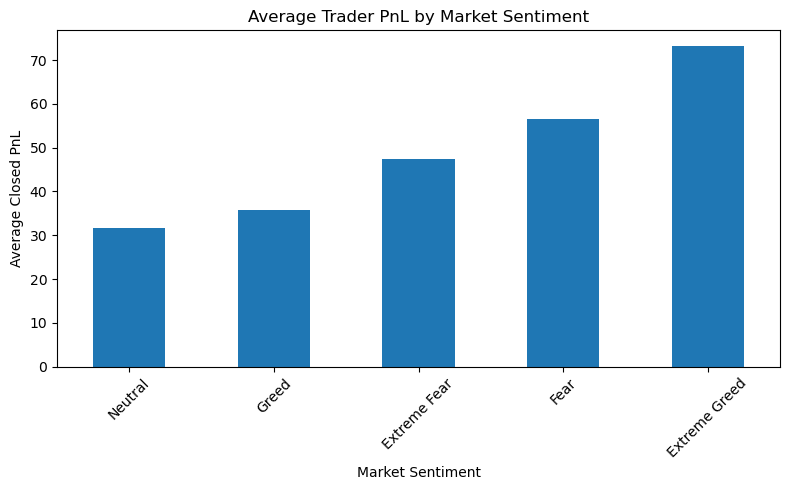

In [9]:
import matplotlib.pyplot as plt

avg_pnl = merged.groupby('classification')['Closed PnL'].mean().sort_values()

plt.figure(figsize=(8,5))
avg_pnl.plot(kind='bar')
plt.title('Average Trader PnL by Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Average Closed PnL')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [10]:
# Buy vs Sell Analysis

merged.groupby('Side')['Closed PnL'].mean()

Side
BUY     36.104730
SELL    60.713803
Name: Closed PnL, dtype: float64

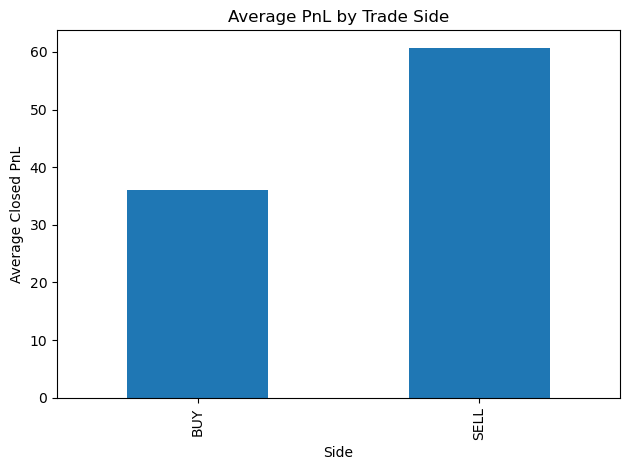

In [11]:
buy_sell = merged.groupby('Side')['Closed PnL'].mean()

import matplotlib.pyplot as plt

buy_sell.plot(kind='bar')

plt.title("Average PnL by Trade Side")
plt.ylabel("Average Closed PnL")
plt.tight_layout()

plt.show()

In [12]:
coin_pnl = merged.groupby('Coin')['Closed PnL'].mean().sort_values(ascending=False).head(10)

print(coin_pnl)

Coin
@109       270.704207
AVAX       239.095613
ENA        219.524751
@85        200.804091
EIGEN      197.063189
PEOPLE     180.323003
DOGE       178.623676
SOL        153.358519
MOODENG    151.096714
ZRO        148.327509
Name: Closed PnL, dtype: float64


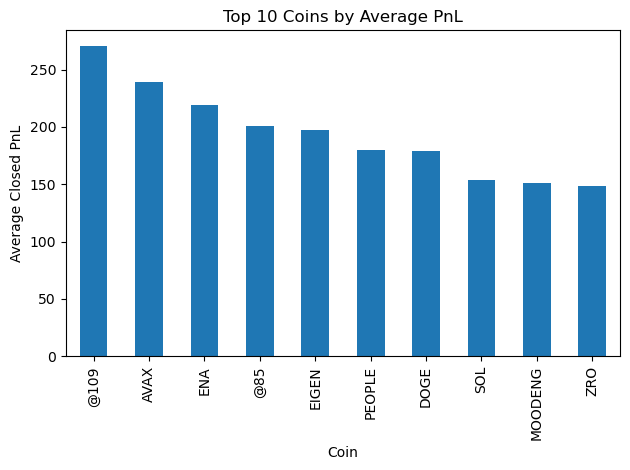

In [13]:
import matplotlib.pyplot as plt

coin_pnl.plot(kind='bar')

plt.title("Top 10 Coins by Average PnL")
plt.ylabel("Average Closed PnL")
plt.tight_layout()

plt.show()

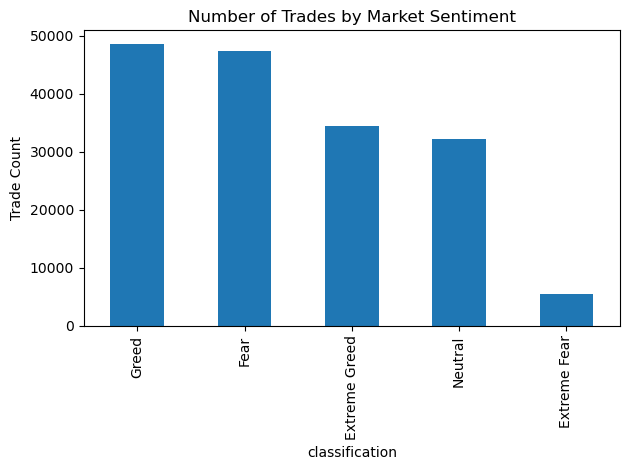

In [14]:
sentiment_count = merged['classification'].value_counts()

sentiment_count.plot(kind='bar')

plt.title("Number of Trades by Market Sentiment")
plt.ylabel("Trade Count")
plt.tight_layout()
plt.show()

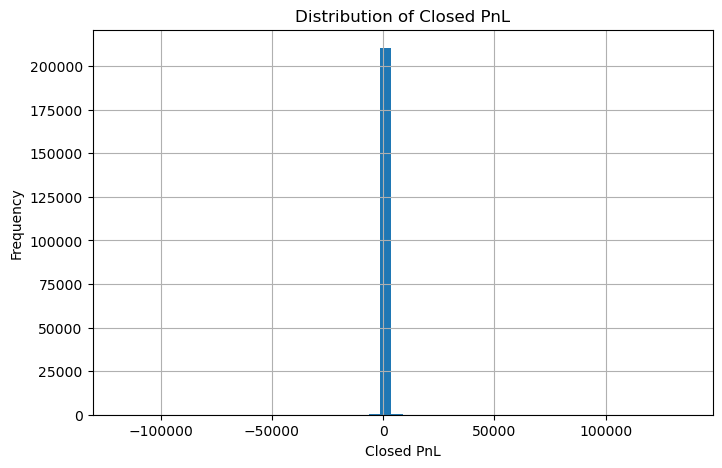

In [15]:
plt.figure(figsize=(8,5))

merged['Closed PnL'].hist(bins=50)

plt.title("Distribution of Closed PnL")
plt.xlabel("Closed PnL")
plt.ylabel("Frequency")
plt.show()